In [47]:
import os
import json
import numpy as np


def load_dataset(main_dirs):
    X = []
    y = []

    for main_dir in main_dirs:
        print(f"Loading data from: {main_dir}")
        for subdir in os.listdir(main_dir):
            subpath = os.path.join(main_dir, subdir)

            if not os.path.isdir(subpath):
                continue

            json_file = os.path.join(subpath, "summary.json")

            if not os.path.exists(json_file):
                continue

            with open(json_file, "r") as f:
                data = json.load(f)
            if not data.get("success", False):
                continue

            try:
                aminor = data["radius"]
                ip = data["ip"]
                bvac = data["bvac"]
                t_eped = data["t_eped"]
                n_eped = data["n_eped"]
                d_ped_te = data["d_ped_te"]
                d_ped_ne = data["d_ped_ne"]
                betan = data["betan"]
                core_slope_te = data["profile_fit"]["te"]["cte"]
                core_slope_ne = data["profile_fit"]["de"]["cde"]

                X.append([
                    aminor,
                    ip,
                    bvac,
                    t_eped,
                    n_eped,
                    d_ped_te,
                    d_ped_ne,
                    core_slope_ne,
                    betan])
                y.append(core_slope_te)

            except KeyError:
                # skip runs with missing data
                continue

    X = np.array(X)
    y = np.array(y)

    return X, y


# Example usage
main_dirs = [
    "/scratch/project_2009007/data_JET_1H/success",
    "/scratch/project_2009007/data_JET_2H/success",
    "/scratch/project_2009007/data_JET_3H/success",
]

X, y = load_dataset(main_dirs)

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

print("First sample features:", X[0])
print("First label:", y[0])

Loading data from: /scratch/project_2009007/data_JET_1H/success
Loading data from: /scratch/project_2009007/data_JET_2H/success
Loading data from: /scratch/project_2009007/data_JET_3H/success
Feature shape: (26416, 9)
Label shape: (26416,)
First sample features: [0.2926     1.8926348  2.20048665 0.26989892 4.23679439 0.02238145
 0.02238145 0.1        0.988     ]
First label: 3.225536294177597


In [52]:
import matplotlib.pyplot as plt
import numpy as np


def plot_feature_histograms(X):

    feature_names = [
        "aminor",
        "ip",
        "bvac",
        "t_eped",
        "n_eped",
        "d_ped_te",
        "d_ped_ne",
        "core_slope_ne",
        "betan"
    ]

    n_features = X.shape[1]

    fig, axes = plt.subplots(3, 3, figsize=(12,10))
    axes = axes.flatten()

    for i in range(n_features):
        axes[i].hist(X[:, i], bins=40)
        axes[i].set_title(feature_names[i])
        axes[i].set_ylabel("Count")


    plt.tight_layout()
    plt.show()

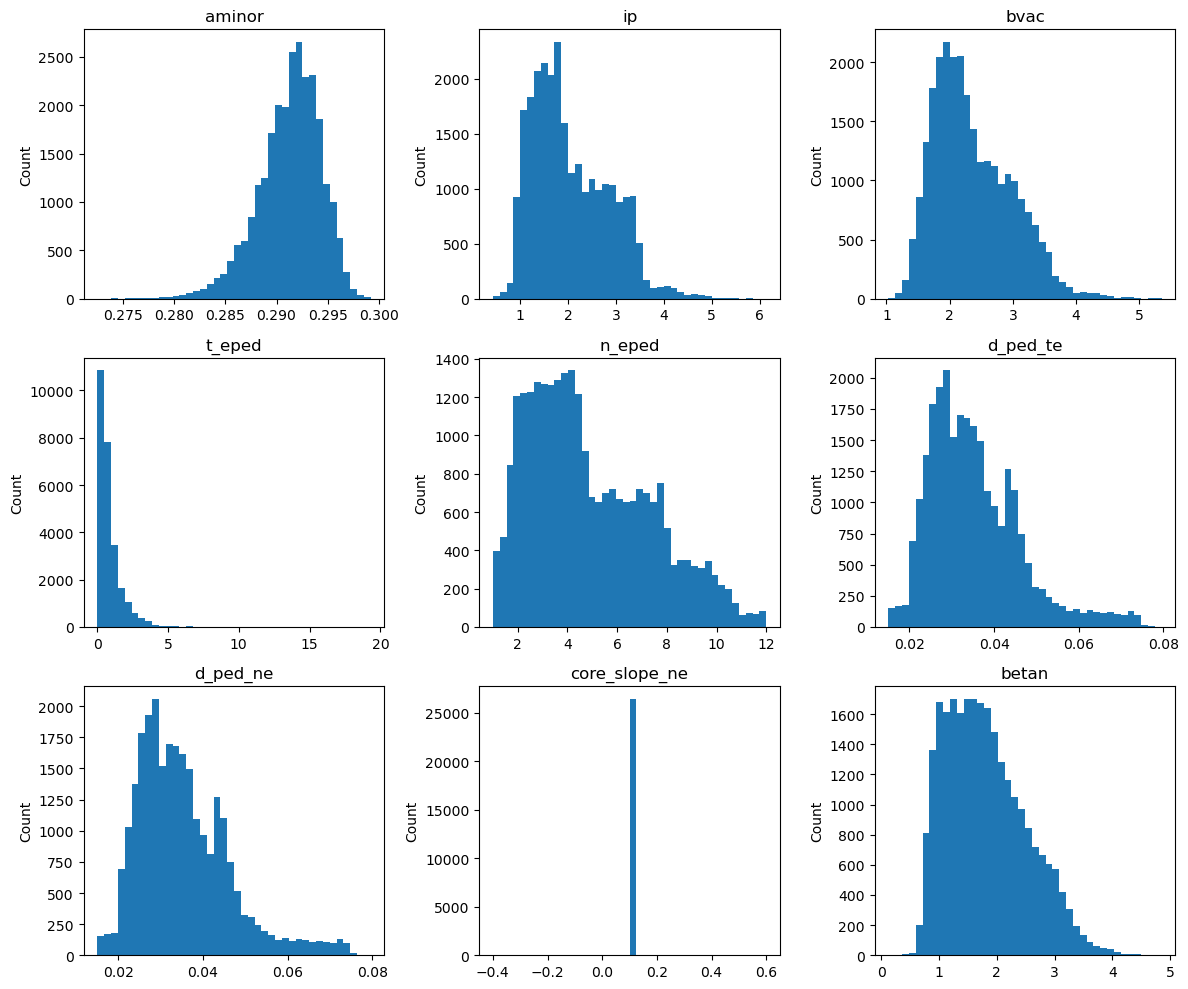

In [53]:
plot_feature_histograms(X)

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [56]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(9,9),
    activation="relu",
    solver="adam",
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [57]:
from sklearn.metrics import mean_squared_error, r2_score

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

RMSE: 0.4020124782770628
R2: 0.9963074727237955


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error


def regression_diagnostics(y_true, y_pred):

    residuals = y_true - y_pred

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    fig, axes = plt.subplots(1, 3, figsize=(15,5))

    # -------------------------
    # 1. True vs Predicted
    # -------------------------
    ax = axes[0]

    ax.scatter(y_true, y_pred, alpha=0.6)

    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))

    ax.plot([min_val, max_val], [min_val, max_val], "--")

    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title(f"True vs Predicted\nR²={r2:.3f}")
    ax.grid(True)

    # -------------------------
    # 2. Residuals vs Prediction
    # -------------------------
    ax = axes[1]

    ax.scatter(y_pred, residuals, alpha=0.6)
    ax.axhline(0, linestyle="--")

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")
    ax.set_title("Residuals vs Prediction")
    ax.grid(True)

    # -------------------------
    # 3. Residual Distribution
    # -------------------------
    ax = axes[2]

    ax.hist(residuals, bins=100)
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")
    ax.set_title(f"Residual Distribution\nMSE={mse:.3e}")
    ax.grid(True)

    plt.tight_layout()
    plt.show()

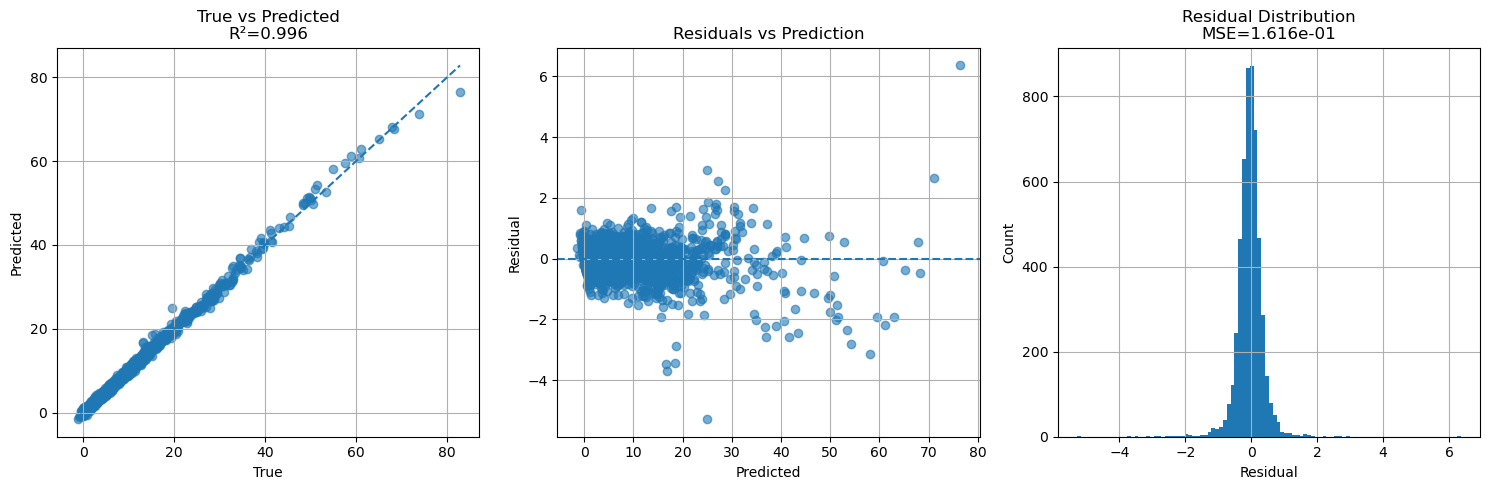

In [59]:
y_pred = model.predict(X_test)

regression_diagnostics(y_test, y_pred)

In [65]:
print(model.coefs_)

[array([[-7.11396350e-02,  8.08866079e-02, -1.36797725e-01,
         4.10274092e-02, -2.16055659e-01, -1.85700503e-01,
         1.41079822e-01,  3.76836719e-01,  6.10917091e-02],
       [ 1.88342881e-01, -3.20338172e-02, -1.96777402e-01,
         3.42556420e-01, -6.41195838e-01, -4.46792460e-01,
        -8.46741838e-03,  3.70234364e-01, -1.13781084e-01],
       [ 4.84437963e-01,  2.08523551e-01,  4.70649027e-01,
         2.36061061e-01, -5.90821038e-01,  6.40683636e-01,
         4.13470251e-01,  6.18954445e-01,  4.89014036e-01],
       [-3.18543667e-02, -9.46177617e-03, -6.56613350e-02,
         2.68466037e-01, -1.06114828e+00, -6.38406344e-01,
         2.22501298e-02,  7.88726422e-01,  2.57110166e-01],
       [-1.59669351e+00, -1.57113265e+00, -2.87019238e-01,
        -4.60322505e-01,  5.82664984e-01, -3.17958210e-01,
        -4.73467925e-01, -5.17967763e-01, -1.72725693e+00],
       [-7.51219203e-02, -4.04452033e-01, -6.67994076e-02,
        -4.89388142e-01, -4.64277389e-02,  2.80754

In [61]:
print(model.intercepts_)

[array([-0.38859538, -2.3381211 ,  1.79796463, -2.26247477, -0.30239228,
        1.12294015,  0.53454367, -0.16142615, -1.84041426]), array([ 0.32840454, -2.08820097, -1.28985836, -0.17002026, -2.07574623,
        0.24567719, -1.68394132,  0.96806966, -0.84762084]), array([-0.11523101])]


In [69]:
model.coefs_

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (3, 9) + inhomogeneous part.

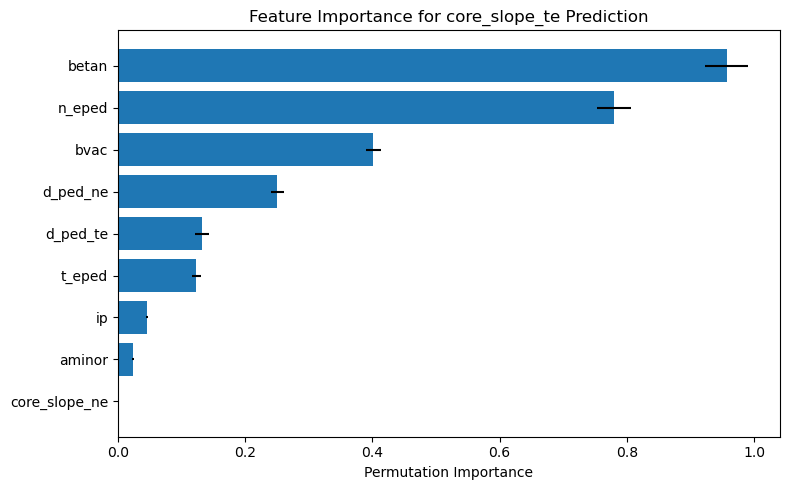

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

feature_names = [
    "aminor",
    "ip",
    "bvac",
    "t_eped",
    "n_eped",
    "d_ped_te",
    "d_ped_ne",
    "core_slope_ne",
    "betan"
]

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)

importance = result.importances_mean
std = result.importances_std

# Sort features by importance
idx = np.argsort(importance)

plt.figure(figsize=(8,5))

plt.barh(np.array(feature_names)[idx], importance[idx], xerr=std[idx])

plt.xlabel("Permutation Importance")
plt.title("Feature Importance for core_slope_te Prediction")

plt.tight_layout()
plt.show()

In [64]:
import joblib

model_dir = "model_9"
joblib.dump(model, os.path.join(model_dir, "core_slope_model.pkl"))
joblib.dump(scaler, os.path.join(model_dir, "feature_scaler.pkl"))

['model_9/feature_scaler.pkl']

## Load existing model


In [ ]:
import joblib

model = joblib.load("core_slope_model.pkl")
scaler = joblib.load("feature_scaler.pkl")

import numpy as np

x = np.array([[ip, bvac, t_eped, n_eped, d_ped_te, d_ped_ne, core_slope_ne, betan]])

x = scaler.transform(x)

prediction = model.predict(x)

print(prediction)